# 05 Ablacion de predictores: clima vs solo casos

Objetivo: aislar cuanto aporta el clima repitiendo, para cada familia de modelos del notebook 03
(SARIMAX, Prophet, XGBoost, LightGBM, LSTM, N-BEATS), la misma configuracion pero quitando las
variables climaticas. El modelo con clima no se vuelve a entrenar: se usa el resultado ya obtenido
en el notebook 03. Los hiperparametros de cada modelo sin clima se buscan de nuevo (GridSearchCV
o busqueda equivalente), para no comparar el modelo sin clima con los hiperparametros optimizados
para el modelo con clima.

Se evalua a un paso (nowcast, igual que la seccion 8 del notebook 03) y a horizonte anticipado
(multi-paso walk-forward, igual que la seccion 9 del notebook 03, mismo HORIZONTES=[1,2,3,4,6]).
Las conclusiones sobre si vale la pena incluir clima estan al final (seccion 8).

## 1 Carga y utilidades

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, ParameterGrid, TimeSeriesSplit
from sklearn.preprocessing import MinMaxScaler

from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from scikeras.wrappers import KerasRegressor

import torch
from pytorch_lightning.callbacks import EarlyStopping as EarlyStoppingPL
from darts import TimeSeries
from darts.models import NBEATSModel

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
tf.random.set_seed(42)
np.random.seed(42)

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / 'data'

df_dep = pd.read_parquet(DATA_DIR / 'processed' / 'dataset_modelado_magdalena.parquet')
df_dep = df_dep.sort_values('fecha_semana').reset_index(drop=True)
df_dep['amplitud'] = df_dep['t2m_max'] - df_dep['t2m_min']
print('Shape:', df_dep.shape)
print('Rango:', df_dep['fecha_semana'].min().date(), '->', df_dep['fecha_semana'].max().date())
print('GPU disponible (torch):', torch.cuda.is_available())

C:\Users\edavi\PROYECTOS\dengue-surveillance-magdalena\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Shape: (940, 10)
Rango: 2006-12-31 -> 2024-12-29


GPU disponible (torch): True


In [2]:
def compute_metrics(y_true, y_pred) -> dict:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae  = float(mean_absolute_error(y_true, y_pred))
    r2   = float(r2_score(y_true, y_pred))
    mask = y_true != 0
    mape = float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100) if mask.any() else float('nan')
    return {'RMSE': round(rmse, 3), 'MAE': round(mae, 3), 'MAPE': round(mape, 2), 'R2': round(r2, 4)}

def print_metrics(nombre, m):
    print(f'{nombre:28s} RMSE={m["RMSE"]:7.2f} | MAE={m["MAE"]:6.2f} | MAPE={m["MAPE"]:6.2f}% | R2={m["R2"]:6.4f}')

## 2 Split temporal (identico al notebook 03)

In [3]:
TRAIN_FRAC, TEST_FRAC = 0.70, 0.30
n = len(df_dep)
n_resto = round(n * TEST_FRAC)

idx_train, idx_resto = list(TimeSeriesSplit(n_splits=2, test_size=n_resto).split(df_dep))[-1]
df_train_dep = df_dep.iloc[idx_train].copy()
df_resto = df_dep.iloc[idx_resto].copy()

n_val = len(df_resto) // 2
df_val_dep = df_resto.iloc[:n_val].copy()
df_test_dep = df_resto.iloc[n_val:].copy()

FECHAS_TRAIN = set(df_train_dep['fecha_semana'])
FECHAS_VAL   = set(df_val_dep['fecha_semana'])
FECHAS_TEST  = set(df_test_dep['fecha_semana'])
df_trainval_dep = pd.concat([df_train_dep, df_val_dep]).sort_values('fecha_semana')
FECHAS_TRAINVAL = FECHAS_TRAIN | FECHAS_VAL

for nombre, d in [('Train', df_train_dep), ('Val', df_val_dep), ('Test', df_test_dep)]:
    print(f'{nombre:5s}: {len(d):4d} sem ({d["fecha_semana"].dt.year.min()}-{d["fecha_semana"].dt.year.max()}) | {len(d)/n:.1%}')

Train:  658 sem (2006-2019) | 70.0%
Val  :  141 sem (2019-2022) | 15.0%
Test :  141 sem (2022-2024) | 15.0%


## 3 Referencia: resultados con clima del notebook 03

No se vuelve a entrenar el modelo con clima. Estos valores se copian de las salidas ya
ejecutadas del notebook 03 (secciones 5 a 8 para el nowcast, seccion 9 para multi-paso) y solo
se usan como referencia para las celdas de interpretacion de cada modelo.

In [ ]:
# Nowcast (h=1): valores impresos en el notebook 03 (mejor combinacion de exogenas/regresores
# para SARIMAX y Prophet; hiperparametros con clima para XGBoost/LightGBM/LSTM/N-BEATS). N-BEATS
# es una red neuronal con entrenamiento no determinista (GPU): estos valores corresponden a la
# corrida vigente del notebook 03, no son bit-a-bit reproducibles de una corrida a otra.
REF_CC_NOWCAST = {
    'SARIMAX':  {'RMSE': 12.565, 'MAE': 9.344, 'MAPE': 23.65, 'R2': 0.8622},
    'Prophet':  {'RMSE': 12.079, 'MAE': 8.791, 'MAPE': 22.81, 'R2': 0.8727},
    'XGBoost':  {'RMSE': 12.40,  'MAE': 9.19,  'MAPE': 24.17, 'R2': 0.8657},
    'LightGBM': {'RMSE': 12.63,  'MAE': 9.09,  'MAPE': 23.80, 'R2': 0.8609},
    'LSTM':     {'RMSE': 11.61,  'MAE': 8.40,  'MAPE': 20.90, 'R2': 0.8823},
    'N-BEATS':  {'RMSE': 13.89,  'MAE': 9.64,  'MAPE': 21.56, 'R2': 0.8317},
}

# Multi-paso: valores de la seccion 9 del notebook 03 (HORIZONTES=[1,2,3,4,6], corrida vigente).
HORIZONTES = [1, 2, 3, 4, 6]
REF_CC_MS = {
    'SARIMAX':  {'R2': [0.86, 0.83, 0.77, 0.71, 0.59], 'RMSE': [12.6, 14.1, 16.3, 18.2, 21.7], 'MAE': [9.3, 10.4, 11.8, 13.1, 15.1]},
    'Prophet':  {'R2': [0.87, 0.84, 0.78, 0.75, 0.65], 'RMSE': [12.1, 13.6, 15.7, 16.9, 20.0], 'MAE': [8.8, 9.7, 11.2, 12.0, 13.8]},
    'XGBoost':  {'R2': [0.87, 0.85, 0.80, 0.77, 0.66], 'RMSE': [12.4, 13.0, 15.1, 16.4, 19.7], 'MAE': [9.2, 9.8, 11.1, 12.2, 14.3]},
    'LightGBM': {'R2': [0.86, 0.84, 0.78, 0.72, 0.54], 'RMSE': [12.6, 13.6, 15.9, 17.9, 22.9], 'MAE': [9.1, 9.8, 11.4, 13.0, 16.3]},
    'LSTM':     {'R2': [0.88, 0.86, 0.82, 0.77, 0.66], 'RMSE': [11.6, 12.7, 14.5, 16.1, 19.6], 'MAE': [8.4, 9.2, 10.2, 11.0, 13.0]},
    'N-BEATS':  {'R2': [0.83, 0.75, 0.63, 0.52, 0.24], 'RMSE': [13.9, 17.0, 20.5, 23.4, 29.4], 'MAE': [9.6, 12.2, 14.7, 17.3, 22.0]},
}
print('Referencia con clima cargada:', list(REF_CC_NOWCAST))

Referencia con clima cargada: ['SARIMAX', 'Prophet', 'XGBoost', 'LightGBM', 'LSTM', 'N-BEATS']


## 4 Features sin clima (identicas al notebook 03, menos clima)

`build_features` es la misma funcion de la seccion 6.1 del notebook 03: genera los rezagos de
clima y de casos. La diferencia esta en `FEATURES_LAGS`, que para los arboles solo toma los
`casos_lag*` (se calculan los rezagos de clima igual, pero no entran como predictor). SARIMAX
corre sin exogenas, Prophet solo con los rezagos de casos como regresores, LSTM con una sola
feature de entrada (`casos`) y N-BEATS sin `past_covariates`.

In [5]:
CLIMA_VARS  = ['precipitacion', 'amplitud', 't2m_media']
LAGS_CLIMA  = [4, 8, 12, 16]
LAGS_TARGET = [1, 2, 4, 8]

def build_features(serie: pd.DataFrame) -> pd.DataFrame:
    out = serie.copy().sort_values('fecha_semana').reset_index(drop=True)
    for var in CLIMA_VARS:
        for lag in LAGS_CLIMA:
            out[f'{var}_lag{lag}'] = out[var].shift(lag)
    for lag in LAGS_TARGET:
        out[f'casos_lag{lag}'] = out['casos'].shift(lag)
    return out.dropna().reset_index(drop=True)

df_feat = build_features(df_dep)
FEATURES_LAGS = [f'casos_lag{l}' for l in LAGS_TARGET]

df_trainval_feat = df_feat[df_feat['fecha_semana'].isin(FECHAS_TRAINVAL)].copy()
df_test_feat     = df_feat[df_feat['fecha_semana'].isin(FECHAS_TEST)].copy()
y_trainval = df_trainval_feat['casos']
y_test     = df_test_feat['casos']

ORDER_SARIMAX = (2, 1, 2)
SEASONAL_SARIMAX = (0, 0, 0, 52)   # mismo orden que el notebook 03 (elegido por auto_arima, sin exog)

print('Features sin clima (arboles):', FEATURES_LAGS)
print('Test:', len(df_test_feat), 'semanas')

Features sin clima (arboles): ['casos_lag1', 'casos_lag2', 'casos_lag4', 'casos_lag8']
Test: 141 semanas


## 5 Utilidades de busqueda y evaluacion

In [6]:
resultados = {}       # nombre -> metricas (nowcast, sin clima)
hiperparametros = {}   # nombre -> mejores hiperparametros encontrados sin clima
modelos = {}           # nombre -> objeto entrenado (para el multi-paso)
FIG = (13, 3.3)

def _plot(fechas, real, pred, nombre, m, color):
    fig, ax = plt.subplots(figsize=FIG)
    ax.plot(fechas, real, color='black', label='Real')
    ax.plot(fechas, pred, color=color, ls='--', label=nombre)
    ax.set_title(f'{nombre} - RMSE={m["RMSE"]} | MAE={m["MAE"]} | R2={m["R2"]}')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

N_SPLITS_CV = 5
tscv = TimeSeriesSplit(n_splits=N_SPLITS_CV)
rmse_scorer = make_scorer(lambda yt, yp: np.sqrt(mean_squared_error(yt, yp)), greater_is_better=False)

def buscar_hiperparametros(estimador, param_grid, X, y):
    grid = GridSearchCV(estimador, param_grid, scoring=rmse_scorer, cv=tscv, n_jobs=-1, refit=True)
    grid.fit(X, y)
    return grid.best_estimator_, grid.best_params_, -grid.best_score_

def eval_sarimax(nombre, color):
    base = df_dep.set_index('fecha_semana').sort_index().copy()
    base['casos_log'] = np.log1p(base['casos'])
    entreno = base[base.index.isin(FECHAS_TRAINVAL)]
    test    = base[base.index.isin(FECHAS_TEST)]
    y_tr, y_te, y_real = entreno['casos_log'], test['casos_log'], test['casos']

    fit = SARIMAX(y_tr, order=ORDER_SARIMAX, seasonal_order=SEASONAL_SARIMAX,
                  enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    modelo_test = fit.append(y_te, refit=False)
    pred_log = modelo_test.predict(start=y_te.index[0], end=y_te.index[-1], dynamic=False)
    pred = np.expm1(pred_log).clip(lower=0)
    m = compute_metrics(y_real.values, pred.values)
    resultados[nombre] = m
    modelos[nombre] = fit
    _plot(y_real.index, y_real.values, pred.values, nombre, m, color)
    print_metrics(nombre, m)
    return m

def eval_prophet(nombre, color):
    base = df_dep.set_index('fecha_semana').sort_index().copy()
    base['casos_log'] = np.log1p(base['casos'])
    cols_ar = []
    for l in LAGS_TARGET:
        col = f'casos_lag{l}_log'
        base[col] = base['casos_log'].shift(l)
        cols_ar.append(col)
    base = base.dropna(subset=cols_ar)
    entreno = base[base.index.isin(FECHAS_TRAINVAL)].reset_index()
    test    = base[base.index.isin(FECHAS_TEST)].reset_index()
    df_entreno = entreno[['fecha_semana', 'casos_log'] + cols_ar].rename(columns={'fecha_semana': 'ds', 'casos_log': 'y'})
    df_test    = test[['fecha_semana', 'casos'] + cols_ar].rename(columns={'fecha_semana': 'ds', 'casos': 'y'})

    modelo = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
    for c in cols_ar:
        modelo.add_regressor(c)
    modelo.fit(df_entreno)
    forecast = modelo.predict(df_test)
    pred = np.expm1(forecast['yhat']).clip(lower=0).values
    m = compute_metrics(df_test['y'].values, pred)
    resultados[nombre] = m
    modelos[nombre] = (modelo, cols_ar)
    _plot(df_test['ds'], df_test['y'].values, pred, nombre, m, color)
    print_metrics(nombre, m)
    return m

def eval_tree_gs(estimador_base, param_grid, nombre, color):
    mejor, best_params, rmse_cv = buscar_hiperparametros(estimador_base, param_grid, df_trainval_feat[FEATURES_LAGS], y_trainval)
    pred = mejor.predict(df_test_feat[FEATURES_LAGS]).clip(min=0)
    m = compute_metrics(y_test.values, pred)
    resultados[nombre] = m
    hiperparametros[nombre] = best_params
    modelos[nombre] = mejor
    _plot(df_test_feat['fecha_semana'], y_test.values, pred, nombre, m, color)
    print(f'Mejores hiperparametros ({nombre}): {best_params} | RMSE CV={rmse_cv:.3f}')
    print_metrics(nombre, m)
    return m

def create_model(input_shape, lstm_units=(64, 32), lstm_activation='tanh', dropout=0.0, optimizer='adam'):
    model = Sequential()
    for i, units in enumerate(lstm_units):
        return_seq = i < len(lstm_units) - 1
        if i == 0:
            model.add(LSTM(units, activation=lstm_activation, return_sequences=return_seq, input_shape=input_shape))
        else:
            model.add(LSTM(units, activation=lstm_activation, return_sequences=return_seq))
        if dropout > 0:
            model.add(Dropout(dropout))
    model.add(Dense(1))
    model.compile(optimizer=optimizer, loss='mean_absolute_error')
    return model

WINDOW = 12

def preparar_lstm(input_feats, window=WINDOW):
    base = df_dep.set_index('fecha_semana').sort_index().copy()
    base['casos_log'] = np.log1p(base['casos'])
    fechas = base.index
    pos_val  = fechas.isin(FECHAS_TRAIN).sum()
    pos_test = pos_val + fechas.isin(FECHAS_VAL).sum()

    Xdf = pd.DataFrame(index=base.index)
    for f in input_feats:
        Xdf[f] = base['casos_log'] if f == 'casos' else base[f]

    x_scaler = MinMaxScaler().fit(Xdf.iloc[:pos_val])
    Xs = x_scaler.transform(Xdf)
    y_scaler = MinMaxScaler().fit(base[['casos_log']].iloc[:pos_val])
    ys = y_scaler.transform(base[['casos_log']]).flatten()

    Xseq, yseq = [], []
    for i in range(window, len(base)):
        Xseq.append(Xs[i - window:i]); yseq.append(ys[i])
    Xseq, yseq = np.array(Xseq), np.array(yseq)

    sp = dict(
        Xtr=Xseq[:pos_val - window],       ytr=yseq[:pos_val - window],
        Xva=Xseq[pos_val - window:pos_test - window], yva=yseq[pos_val - window:pos_test - window],
        Xte=Xseq[pos_test - window:],      yte=yseq[pos_test - window:],
    )
    fechas_test = fechas[pos_test:]

    def inv(a):
        a = np.asarray(a).reshape(-1, 1)
        return np.expm1(y_scaler.inverse_transform(a).flatten()).clip(min=0)

    return sp, inv, fechas_test, y_scaler

ACCEL_NB = 'gpu' if torch.cuda.is_available() else 'cpu'

def build_nbeats(input_chunk_length=16, num_blocks=1, num_layers=2, layer_widths=256, dropout=0.1, n_epochs=200):
    early_stop = EarlyStoppingPL(monitor='val_loss', patience=20, min_delta=1e-4, mode='min')
    return NBEATSModel(input_chunk_length=input_chunk_length, output_chunk_length=1, num_blocks=num_blocks,
                        num_layers=num_layers, layer_widths=layer_widths, dropout=dropout, n_epochs=n_epochs,
                        batch_size=16, random_state=42,
                        pl_trainer_kwargs={'enable_progress_bar': False, 'accelerator': ACCEL_NB,
                                           'devices': 1, 'callbacks': [early_stop]})

print('Utilidades listas.')

Utilidades listas.


## 6 Baseline: persistencia (y_t = y_{t-1})

In [7]:
serie = df_dep.set_index('fecha_semana')['casos']
persist_pred = serie.shift(1).reindex(df_test_feat['fecha_semana']).values
m_persist = compute_metrics(y_test.values, persist_pred)
resultados['Persistencia'] = m_persist
print_metrics('Persistencia', m_persist)

Persistencia                 RMSE=  13.21 | MAE=  9.95 | MAPE= 26.11% | R2=0.8477


## 7 Modelos sin clima (nowcast)

### 7.1 SARIMAX

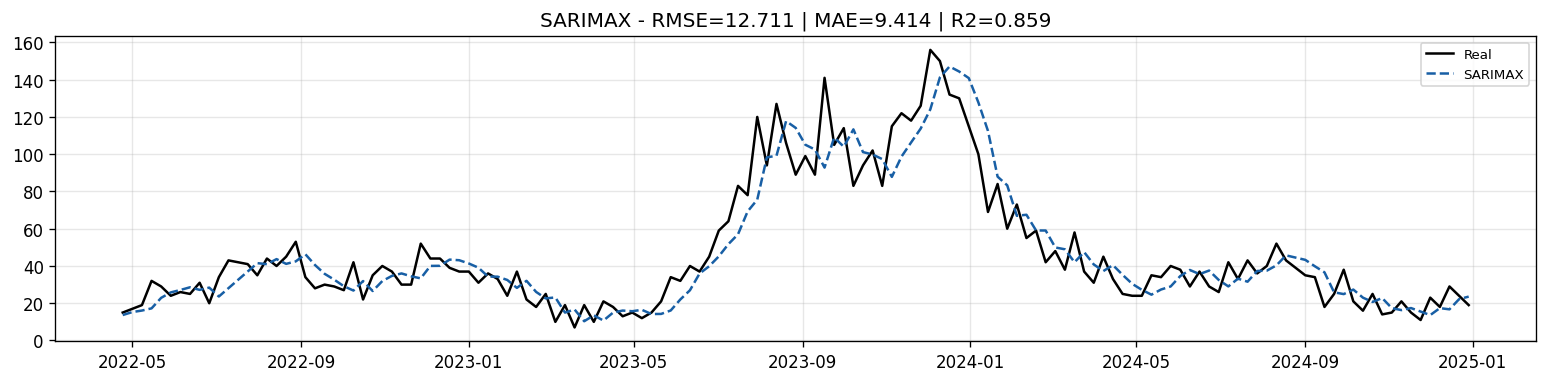

SARIMAX                      RMSE=  12.71 | MAE=  9.41 | MAPE= 23.56% | R2=0.8590


In [8]:
eval_sarimax('SARIMAX', '#185FA5');

Con clima (notebook 03, mejor combinacion de exogenas): RMSE=12.57, R2=0.8622. Sin clima: RMSE=12.71, R2=0.8590. La diferencia es minima (R2 -0.003): a un paso, SARIMAX ya captura casi toda la senal con el propio pasado de la serie, y el aporte de las exogenas climaticas es marginal, coherente con lo que la seccion 5.1 del notebook 03 ya habia encontrado (+0.15 RMSE).

### 7.2 Prophet

01:22:21 - cmdstanpy - INFO - Chain [1] start processing


01:22:21 - cmdstanpy - INFO - Chain [1] done processing


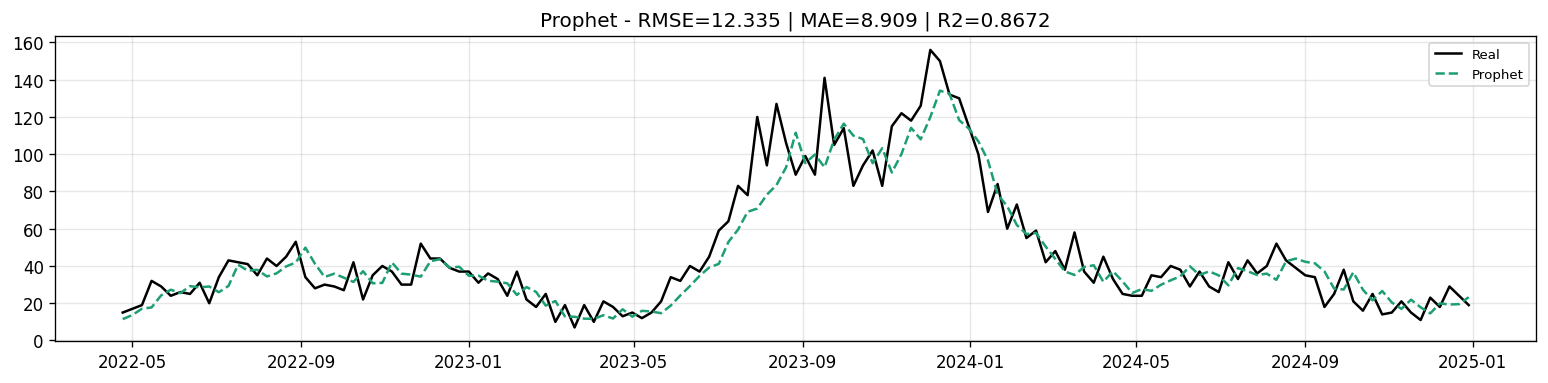

Prophet                      RMSE=  12.34 | MAE=  8.91 | MAPE= 23.07% | R2=0.8672


In [9]:
eval_prophet('Prophet', '#1D9E75');

Con clima (mejor combinacion de regresores): RMSE=12.08, R2=0.8727. Sin clima (solo autorregresivo): RMSE=12.34, R2=0.8672. Mejora marginal, similar a SARIMAX (R2 -0.006). Prophet-AR sin clima ya es, de los seis, el mejor modelo del nowcast sin clima.

### 7.3 XGBoost

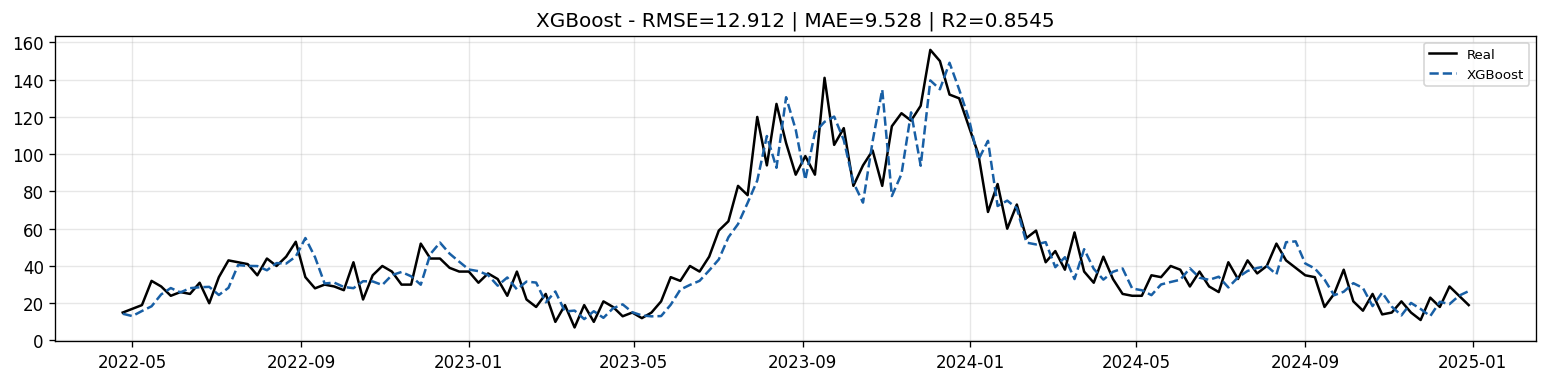

Mejores hiperparametros (XGBoost): {'learning_rate': 0.04, 'max_depth': 2, 'min_child_weight': 5, 'n_estimators': 300} | RMSE CV=13.346
XGBoost                      RMSE=  12.91 | MAE=  9.53 | MAPE= 24.65% | R2=0.8545


In [10]:
XGB_PARAM_GRID = {
    'max_depth': [2, 3, 4],
    'learning_rate': [0.03, 0.04, 0.05],
    'n_estimators': [200, 300, 400],
    'min_child_weight': [3, 5, 7],
}
xgb_base = XGBRegressor(random_state=42, n_jobs=-1, subsample=0.8, colsample_bytree=0.8, reg_lambda=3)
eval_tree_gs(xgb_base, XGB_PARAM_GRID, 'XGBoost', '#185FA5');

Con clima: RMSE=12.40, R2=0.8657 (hiperparametros originales: max_depth=2, learning_rate=0.04, min_child_weight=3, n_estimators=300). Sin clima, con busqueda propia: RMSE=12.91, R2=0.8545 (min_child_weight sube a 5, el resto igual). La caida es mayor que en los modelos estadisticos (R2 -0.011): sin clima, XGBoost pierde parte de su capacidad de ajuste.

### 7.4 LightGBM

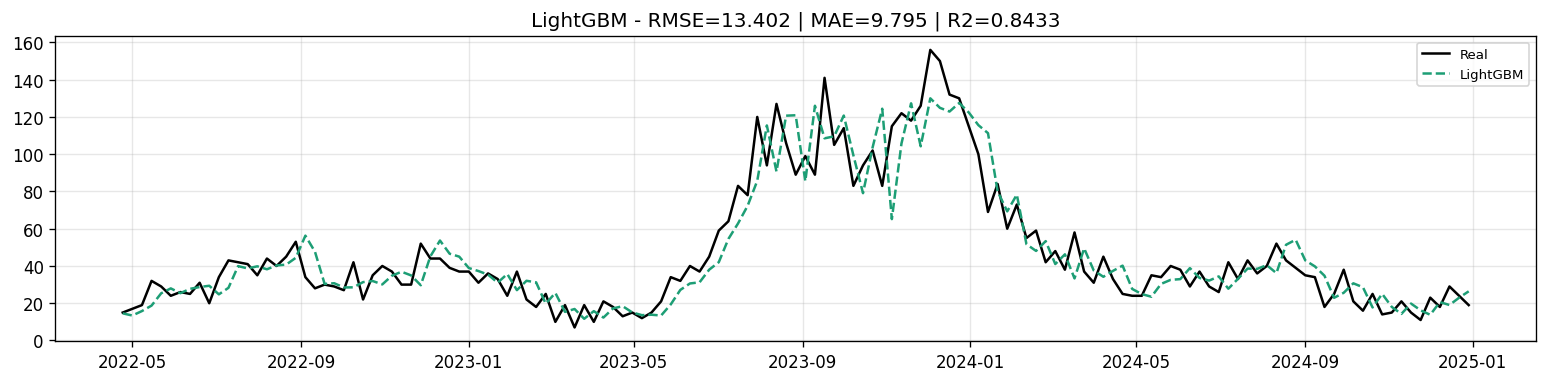

Mejores hiperparametros (LightGBM): {'learning_rate': 0.03, 'min_child_samples': 10, 'n_estimators': 200, 'num_leaves': 7} | RMSE CV=13.898
LightGBM                     RMSE=  13.40 | MAE=  9.79 | MAPE= 25.00% | R2=0.8433


In [11]:
LGBM_PARAM_GRID = {
    'num_leaves': [7, 15, 31],
    'learning_rate': [0.01, 0.02, 0.03],
    'n_estimators': [200, 300, 400],
    'min_child_samples': [10, 20, 30],
}
lgbm_base = LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1, subsample=0.8, subsample_freq=1,
                          colsample_bytree=0.8, reg_lambda=3)
eval_tree_gs(lgbm_base, LGBM_PARAM_GRID, 'LightGBM', '#1D9E75');

Con clima: RMSE=12.63, R2=0.8609. Sin clima: RMSE=13.40, R2=0.8433 (hiperparametros: num_leaves=7, learning_rate=0.03, n_estimators=200, min_child_samples=10, igual busqueda que la del modelo con clima). Es el primer caso donde el modelo sin clima queda por debajo de la persistencia (RMSE=13.21): con solo 4 rezagos de casos, LightGBM no logra superar la inercia de la serie.

### 7.5 LSTM (ventana de casos)

In [12]:
LSTM_FEATURES = ['casos']
sp_lstm, inv_lstm, fechas_test_lstm, y_scaler_lstm = preparar_lstm(LSTM_FEATURES)
INPUT_SHAPE = (WINDOW, len(LSTM_FEATURES))
Xtv_lstm = np.concatenate([sp_lstm['Xtr'], sp_lstm['Xva']])
ytv_lstm = np.concatenate([sp_lstm['ytr'], sp_lstm['yva']])

regressor = KerasRegressor(model=create_model, model__input_shape=INPUT_SHAPE, verbose=0)
param_dnn = {
    'model__lstm_units': [(64, 16), (64, 32)],
    'model__lstm_activation': ['tanh'],
    'model__dropout': [0.2],
    'model__optimizer': ['adam', 'rmsprop'],
    'batch_size': [16],
    'epochs': [40],
}
grid_dnn = GridSearchCV(regressor, param_dnn, scoring=rmse_scorer, cv=tscv, n_jobs=1)
grid_dnn.fit(Xtv_lstm, ytv_lstm)
best_params_lstm = grid_dnn.best_params_
print('Mejores hiperparametros LSTM (sin clima):', best_params_lstm)

Mejores hiperparametros LSTM (sin clima): {'batch_size': 16, 'epochs': 40, 'model__dropout': 0.2, 'model__lstm_activation': 'tanh', 'model__lstm_units': (64, 16), 'model__optimizer': 'rmsprop'}


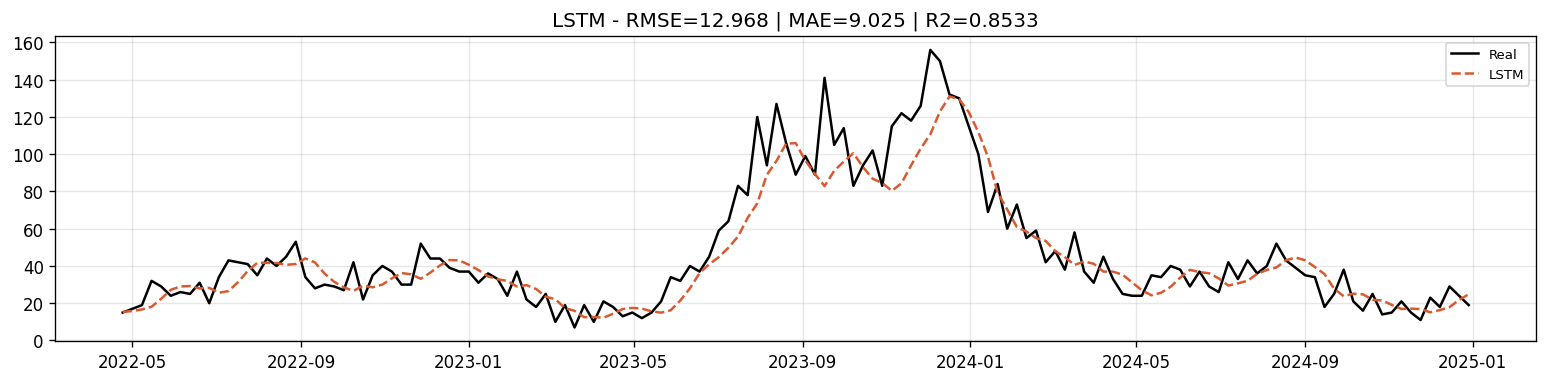

LSTM                         RMSE=  12.97 | MAE=  9.03 | MAPE= 22.40% | R2=0.8533


In [13]:
PARAMS_LSTM = {k.replace('model__', ''): v for k, v in best_params_lstm.items() if k.startswith('model__')}
BATCH_LSTM = best_params_lstm['batch_size']

tf.keras.utils.set_random_seed(42)
model_lstm = create_model(input_shape=INPUT_SHAPE, **PARAMS_LSTM)
cbs = [EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
       ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-5)]
model_lstm.fit(sp_lstm['Xtr'], sp_lstm['ytr'], validation_data=(sp_lstm['Xva'], sp_lstm['yva']),
              epochs=200, batch_size=BATCH_LSTM, callbacks=cbs, verbose=0)

pred_lstm = inv_lstm(model_lstm.predict(sp_lstm['Xte'], verbose=0).flatten())
real_lstm = inv_lstm(sp_lstm['yte'])
m_lstm = compute_metrics(real_lstm, pred_lstm)
resultados['LSTM'] = m_lstm
hiperparametros['LSTM'] = {**PARAMS_LSTM, 'batch_size': BATCH_LSTM}
modelos['LSTM'] = model_lstm
_plot(fechas_test_lstm[:len(real_lstm)], real_lstm, pred_lstm, 'LSTM', m_lstm, '#D85A30')
print_metrics('LSTM', m_lstm)

Con clima: RMSE=11.61, R2=0.8823. Sin clima: RMSE=12.97, R2=0.8533 (arquitectura re-buscada: unidades (64, 16), optimizer rmsprop, distinta a la de con clima). La caida (R2 -0.029) es la segunda mayor del nowcast, despues de N-BEATS: la ventana de clima le aportaba senal real a la LSTM, no solo ruido.

### 7.6 N-BEATS (sin past_covariates)

In [14]:
serie_casos_log = np.log1p(df_dep.set_index('fecha_semana')['casos'])
ts_full = TimeSeries.from_series(serie_casos_log, freq='W-SUN')
fechas_orden_nb = df_dep.sort_values('fecha_semana')['fecha_semana']
n_train_nb = fechas_orden_nb.isin(FECHAS_TRAIN).sum()
n_val_nb   = fechas_orden_nb.isin(FECHAS_VAL).sum()
ts_train = ts_full[:n_train_nb]
ts_val   = ts_full[n_train_nb:n_train_nb + n_val_nb]
ts_test  = ts_full[n_train_nb + n_val_nb:]

NBEATS_GRID = {
    'input_chunk_length': [12, 26, 52],
    'num_blocks': [1, 2],
    'num_layers': [2],
    'layer_widths': [64, 128],
    'dropout': [0.1],
}
filas_nb = []
for params in ParameterGrid(NBEATS_GRID):
    m_ = build_nbeats(**params, n_epochs=150)
    m_.fit(ts_train, val_series=ts_val, verbose=False)
    pred_val = m_.historical_forecasts(series=ts_full[:n_train_nb + n_val_nb], start=n_train_nb,
                start_format='position', forecast_horizon=1, stride=1, retrain=False,
                last_points_only=True, verbose=False)
    real_v = np.expm1(ts_val.slice_intersect(pred_val).values().flatten()).clip(min=0)
    pred_v = np.expm1(pred_val.slice_intersect(ts_val).values().flatten()).clip(min=0)
    filas_nb.append({**params, 'val_RMSE': round(float(np.sqrt(mean_squared_error(real_v, pred_v))), 3)})

df_nbeats_search = pd.DataFrame(filas_nb).sort_values('val_RMSE').reset_index(drop=True)
print(df_nbeats_search.to_string(index=False))
best_params_nbeats = {k: int(df_nbeats_search.iloc[0][k]) for k in NBEATS_GRID}
print('Mejores hiperparametros N-BEATS (sin clima):', best_params_nbeats)

GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


HPU available: False, using: 0 HPUs


You are using a CUDA device ('NVIDIA GeForce RTX 3050 6GB Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


...

GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


HPU available: False, using: 0 HPUs


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


 dropout  input_chunk_length  layer_widths  num_blocks  num_layers  val_RMSE
     0.1                  12           128           1           2     8.430
     0.1                  12            64           1           2     8.599
     0.1                  12            64           2           2     8.912
     0.1                  12           128           2           2     9.318
     0.1                  26            64           2           2     9.550
     0.1                  26            64           1           2     9.585
     0.1                  52           128           1           2    10.744
     0.1                  26           128           1           2    11.870
     0.1                  52            64           1           2    12.020
     0.1                  26           128           2           2    12.063
     0.1                  52            64           2           2    13.116
     0.1                  52           128           2           2    14.682

GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


HPU available: False, using: 0 HPUs


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


HPU available: False, using: 0 HPUs


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


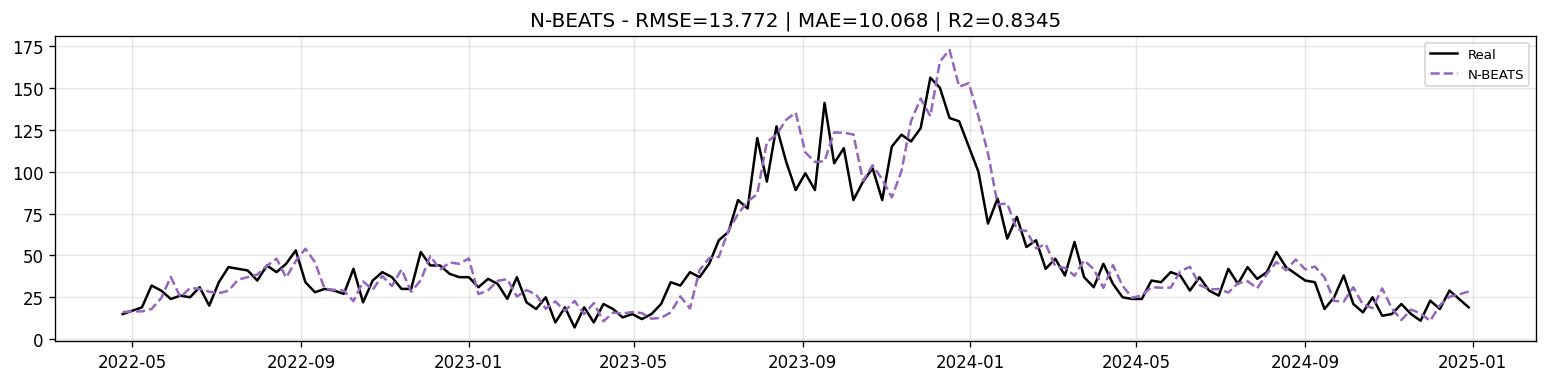

N-BEATS                      RMSE=  13.77 | MAE= 10.07 | MAPE= 25.99% | R2=0.8345


In [15]:
PARAMS_NBEATS = dict(best_params_nbeats)
model_nbeats = build_nbeats(**PARAMS_NBEATS, n_epochs=200)
model_nbeats.fit(ts_train, val_series=ts_val, verbose=False)

pred_ts = model_nbeats.historical_forecasts(series=ts_full, start=n_train_nb + n_val_nb, start_format='position',
            forecast_horizon=1, stride=1, retrain=False, last_points_only=True, verbose=False)
pred_al = pred_ts.slice_intersect(ts_test)
real_al = ts_test.slice_intersect(pred_ts)
pred_nbeats = np.expm1(pred_al.values().flatten()).clip(min=0)
real_nbeats = np.expm1(real_al.values().flatten()).clip(min=0)
m_nbeats = compute_metrics(real_nbeats, pred_nbeats)
resultados['N-BEATS'] = m_nbeats
hiperparametros['N-BEATS'] = PARAMS_NBEATS
modelos['N-BEATS'] = model_nbeats

fig, ax = plt.subplots(figsize=FIG)
ax.plot(pred_al.time_index, real_nbeats, color='black', label='Real')
ax.plot(pred_al.time_index, pred_nbeats, color='#9467bd', ls='--', label='N-BEATS')
ax.set_title(f"N-BEATS - RMSE={m_nbeats['RMSE']} | MAE={m_nbeats['MAE']} | R2={m_nbeats['R2']}")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print_metrics('N-BEATS', m_nbeats)

Con clima (past_covariates): RMSE=13.89, R2=0.8317. Sin clima: RMSE=13.77, R2=0.8345, practicamente empatados en nowcast. La version con clima de esta corrida entreno peor de lo habitual: N-BEATS es una red no determinista en GPU y su desempeño varia de corrida en corrida (ver seccion 3). La comparacion honesta para N-BEATS no esta en el nowcast sino en el multi-paso (seccion 9): ahi la brecha es enorme y consistente.

## 8 Comparacion nowcast: con clima vs sin clima

  Modelo          Version   RMSE    MAE  MAPE     R2
 SARIMAX Con clima (nb03) 12.565  9.344 23.65 0.8622
 SARIMAX        Sin clima 12.711  9.414 23.56 0.8590
 Prophet Con clima (nb03) 12.079  8.791 22.81 0.8727
 Prophet        Sin clima 12.335  8.909 23.07 0.8672
 XGBoost Con clima (nb03) 12.400  9.190 24.17 0.8657
 XGBoost        Sin clima 12.912  9.528 24.65 0.8545
LightGBM Con clima (nb03) 12.630  9.090 23.80 0.8609
LightGBM        Sin clima 13.402  9.795 25.00 0.8433
    LSTM Con clima (nb03) 11.610  8.400 20.90 0.8823
    LSTM        Sin clima 12.968  9.025 22.40 0.8533
 N-BEATS Con clima (nb03) 13.890  9.640 21.56 0.8317
 N-BEATS        Sin clima 13.772 10.068 25.99 0.8345


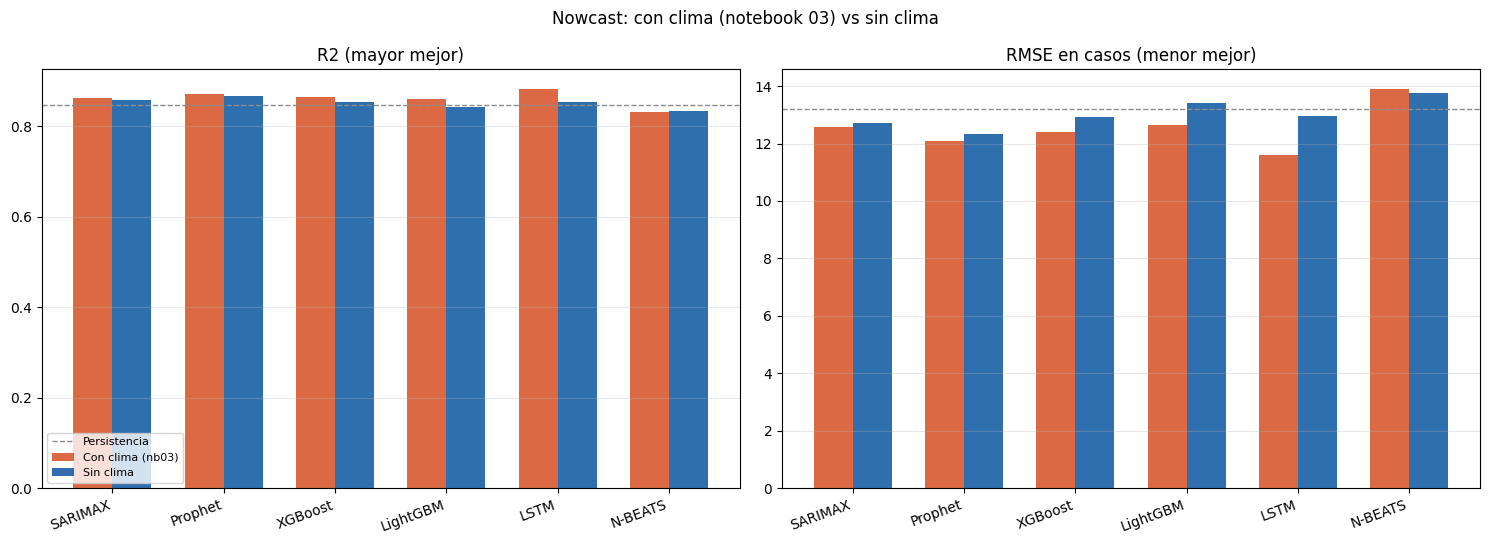

In [ ]:
ORDEN = ['SARIMAX', 'Prophet', 'XGBoost', 'LightGBM', 'LSTM', 'N-BEATS']
filas = []
for nom in ORDEN:
    filas.append({'Modelo': nom, 'Version': 'Con clima (nb03)', **REF_CC_NOWCAST[nom]})
    filas.append({'Modelo': nom, 'Version': 'Sin clima', **resultados[nom]})
df_comp_cc = pd.DataFrame(filas)
print(df_comp_cc.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
x = np.arange(len(ORDEN))
w = 0.35
for ax, met, titulo in [(axes[0], 'R2', 'R2 (mayor mejor)'), (axes[1], 'RMSE', 'RMSE en casos (menor mejor)')]:
    con = [REF_CC_NOWCAST[m][met] for m in ORDEN]
    sin = [resultados[m][met] for m in ORDEN]
    ax.bar(x - w/2, con, width=w, color='#D85A30', alpha=0.9, label='Con clima (nb03)')
    ax.bar(x + w/2, sin, width=w, color='#185FA5', alpha=0.9, label='Sin clima')
    ax.axhline(m_persist[met], color='#8c8c8c', ls='--', lw=1, label='Persistencia')
    ax.set_xticks(x); ax.set_xticklabels(ORDEN, rotation=20, ha='right')
    ax.set_title(titulo); ax.grid(axis='y', alpha=0.3)
axes[0].legend(fontsize=8)
plt.suptitle('Nowcast: con clima (notebook 03) vs sin clima')
plt.tight_layout(); plt.show()

## 9 Evaluacion multi-paso (horizontes 1, 2, 4, 6, 8 semanas)

Mismo andamiaje de la seccion 9 del notebook 03 (walk-forward, origen movil), aplicado a
los seis modelos sin clima. La linea base de persistencia se recalcula aqui (no depende del
clima). Los valores "con clima" de referencia estan en `REF_CC_MS` (seccion 3).

In [17]:
H_MAX = max(HORIZONTES)
serie_casos_ms = df_dep.set_index('fecha_semana')['casos'].sort_index()
fechas_ms = list(serie_casos_ms.index)
N_ms = len(fechas_ms)
casos_ms = serie_casos_ms.values.astype(float)
casos_log_ms = np.log1p(casos_ms)

pos_test_ms = {fechas_ms.index(d) for d in FECHAS_TEST}
first_test_ms, last_test_ms = min(pos_test_ms), max(pos_test_ms)
O_MIN = max(first_test_ms - H_MAX, 60)

def evaluar_multistep(path_fn):
    buckets = {h: ([], []) for h in HORIZONTES}
    for o in range(O_MIN, last_test_ms):
        path = path_fn(o)
        for h in HORIZONTES:
            tp = o + h
            if tp > last_test_ms or tp not in pos_test_ms:
                continue
            buckets[h][0].append(casos_ms[tp])
            buckets[h][1].append(path[h - 1])
    return {h: compute_metrics(np.asarray(y), np.asarray(yh)) for h, (y, yh) in buckets.items()}

def path_persistencia(o):
    return np.full(H_MAX, casos_ms[o], dtype=float)

print(f'Origenes de evaluacion: {O_MIN}..{last_test_ms - 1} | horizontes: {HORIZONTES}')

Origenes de evaluacion: 793..938 | horizontes: [1, 2, 3, 4, 6]


In [18]:
# --- SARIMAX: refit sin exogenas, pronostico recursivo ---
_sx_y_full = np.log1p(df_dep.set_index('fecha_semana').sort_index()['casos'])
_sx_mask_tv = _sx_y_full.index.isin(FECHAS_TRAINVAL)
_sx_fit0 = SARIMAX(_sx_y_full[_sx_mask_tv], order=ORDER_SARIMAX, seasonal_order=SEASONAL_SARIMAX,
                   enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

def path_sarimax_ms(o):
    endog = _sx_y_full.iloc[:o + 1]
    res = _sx_fit0.apply(endog, refit=False)
    steps = min(H_MAX, N_ms - 1 - o)
    fc = res.get_forecast(steps=steps).predicted_mean
    out = np.full(H_MAX, np.nan)
    out[:steps] = np.expm1(np.asarray(fc)).clip(min=0)
    return out


# --- Prophet: refit AR-only, pronostico recursivo con realimentacion ---
_ph_base = df_dep.set_index('fecha_semana').sort_index().copy()
_ph_base['casos_log'] = np.log1p(_ph_base['casos'])
for l in LAGS_TARGET:
    _ph_base[f'casos_lag{l}_log'] = _ph_base['casos_log'].shift(l)
_ph_ar_cols = [f'casos_lag{l}_log' for l in LAGS_TARGET]
_ph_tv = _ph_base[_ph_base.index.isin(FECHAS_TRAINVAL)].dropna(subset=_ph_ar_cols)
_dtr = _ph_tv.reset_index()[['fecha_semana', 'casos_log'] + _ph_ar_cols].rename(columns={'fecha_semana': 'ds', 'casos_log': 'y'})
_ph_model_ms = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
for c in _ph_ar_cols:
    _ph_model_ms.add_regressor(c)
_ph_model_ms.fit(_dtr)

def path_prophet_ms(o):
    histlog = {p: casos_log_ms[p] for p in range(o - max(LAGS_TARGET), o + 1)}
    out = np.full(H_MAX, np.nan)
    for k in range(1, H_MAX + 1):
        tp = o + k
        if tp >= N_ms:
            continue
        fila = {'ds': fechas_ms[tp]}
        for l in LAGS_TARGET:
            fila[f'casos_lag{l}_log'] = histlog[tp - l]
        yhl = float(_ph_model_ms.predict(pd.DataFrame([fila]))['yhat'].iloc[0])
        histlog[tp] = yhl
        out[k - 1] = max(np.expm1(yhl), 0.0)
    return out

print('SARIMAX y Prophet (sin clima) listos para multi-paso.')

01:46:12 - cmdstanpy - INFO - Chain [1] start processing


01:46:12 - cmdstanpy - INFO - Chain [1] done processing


SARIMAX y Prophet (sin clima) listos para multi-paso.


In [19]:
# --- Arboles: recursivo, reconstruye build_features realimentando la prediccion ---
_arbol_base = df_dep.sort_values('fecha_semana')[['fecha_semana', 'casos'] + CLIMA_VARS].reset_index(drop=True)

def _path_arbol(modelo):
    def pf(o):
        work = _arbol_base.copy()
        work.loc[work.index > o, 'casos'] = np.nan
        out = np.full(H_MAX, np.nan)
        for k in range(1, H_MAX + 1):
            tp = o + k
            if tp >= N_ms:
                continue
            work.loc[tp, 'casos'] = 0.0
            feats = build_features(work.iloc[:tp + 1])
            x = feats.iloc[[-1]][FEATURES_LAGS]
            yh = max(float(modelo.predict(x)[0]), 0.0)
            work.loc[tp, 'casos'] = yh
            out[k - 1] = yh
        return out
    return pf

path_xgb_ms = _path_arbol(modelos['XGBoost'])
path_lgbm_ms = _path_arbol(modelos['LightGBM'])


# --- LSTM: recursivo deslizando la ventana (una sola feature: casos) ---
def path_lstm_ms(o, window=WINDOW):
    hist = casos_log_ms[o - window + 1:o + 1].copy()
    out = np.full(H_MAX, np.nan)
    for k in range(1, H_MAX + 1):
        tp = o + k
        if tp >= N_ms:
            continue
        win_scaled = y_scaler_lstm.transform(hist.reshape(-1, 1)).reshape(1, window, 1)
        ys = float(model_lstm.predict(win_scaled, verbose=0).flatten()[0])
        y_log = float(y_scaler_lstm.inverse_transform([[ys]])[0, 0])
        out[k - 1] = max(np.expm1(y_log), 0.0)
        hist = np.append(hist[1:], y_log)
    return out


# --- N-BEATS: historical_forecasts sin past_covariates, por horizonte ---
_n_train_ms = pd.Index(fechas_ms).isin(FECHAS_TRAIN).sum()
_n_val_ms = pd.Index(fechas_ms).isin(FECHAS_VAL).sum()
_nb_start = int(_n_train_ms + _n_val_ms - H_MAX)

def evaluar_nbeats_ms():
    salida = {}
    for h in HORIZONTES:
        hf = model_nbeats.historical_forecasts(series=ts_full, start=_nb_start, start_format='position',
                    forecast_horizon=h, stride=1, retrain=False, last_points_only=True, verbose=False)
        s = pd.Series(np.expm1(hf.values().flatten()).clip(min=0), index=hf.time_index)
        s = s[[d in FECHAS_TEST for d in s.index]]
        y = serie_casos_ms.reindex(s.index).values
        salida[h] = compute_metrics(y, s.values)
    return salida

print('Arboles, LSTM y N-BEATS (sin clima) listos para multi-paso.')

Arboles, LSTM y N-BEATS (sin clima) listos para multi-paso.


In [20]:
resultados_ms = {
    'Persistencia': evaluar_multistep(path_persistencia),
    'SARIMAX':      evaluar_multistep(path_sarimax_ms),
    'Prophet':      evaluar_multistep(path_prophet_ms),
    'XGBoost':      evaluar_multistep(path_xgb_ms),
    'LightGBM':     evaluar_multistep(path_lgbm_ms),
    'LSTM':         evaluar_multistep(path_lstm_ms),
    'N-BEATS':      evaluar_nbeats_ms(),
}
df_ms = pd.DataFrame([
    {'Modelo': modelo, 'H (sem)': h, **resultados_ms[modelo][h]}
    for modelo in resultados_ms for h in HORIZONTES
])
print(df_ms.to_string(index=False))

GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


HPU available: False, using: 0 HPUs


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


GPU available: True (cuda), used: True


...

GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


HPU available: False, using: 0 HPUs


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


      Modelo  H (sem)   RMSE    MAE  MAPE      R2
Persistencia        1 13.211  9.950 26.11  0.8477
Persistencia        2 14.007 10.440 25.90  0.8288
Persistencia        3 17.543 12.702 30.76  0.7315
Persistencia        4 19.942 14.929 36.52  0.6530
Persistencia        6 24.926 17.702 44.25  0.4579
     SARIMAX        1 12.711  9.414 23.56  0.8590
     SARIMAX        2 14.809 11.068 26.33  0.8086
     SARIMAX        3 17.419 12.748 30.24  0.7352
     SARIMAX        4 19.812 14.363 34.82  0.6575
     SARIMAX        6 24.640 17.262 42.69  0.4702
     Prophet        1 12.335  8.909 23.07  0.8672
     Prophet        2 14.027 10.062 24.64  0.8283
     Prophet        3 16.292 11.638 28.45  0.7684
     Prophet        4 17.468 12.415 30.75  0.7337
     Prophet        6 20.761 14.152 35.37  0.6239
     XGBoost        1 12.912  9.528 24.65  0.8545
     XGBoost        2 13.937 10.112 26.48  0.8305
     XGBoost        3 15.884 11.807 30.42  0.7798
     XGBoost        4 17.804 13.361 35.29  0.7234


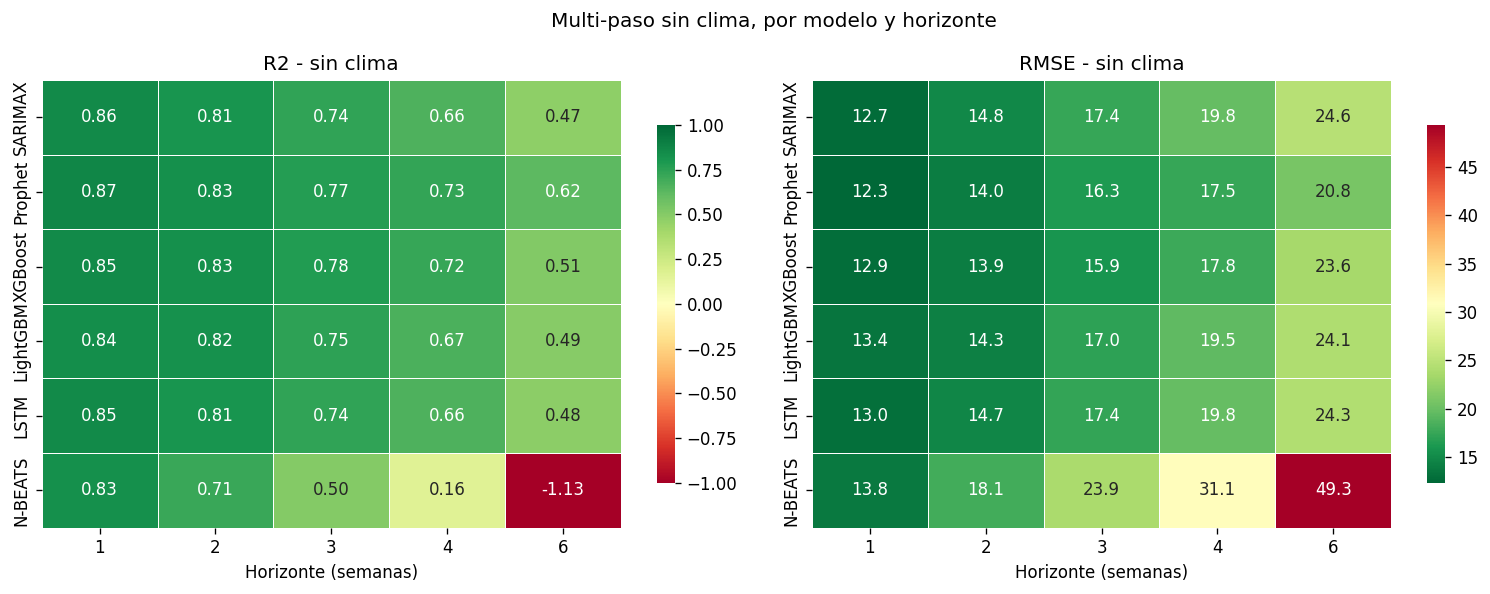

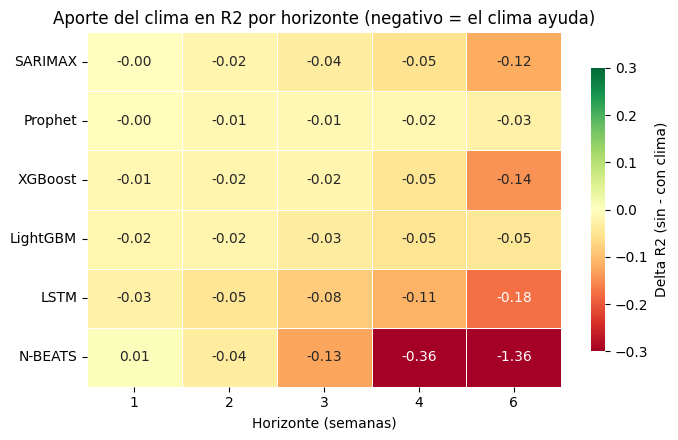

In [ ]:
ORDEN_MS = ['SARIMAX', 'Prophet', 'XGBoost', 'LightGBM', 'LSTM', 'N-BEATS']

specs = [('R2', 'RdYlGn', '.2f', 0, -1, 1), ('RMSE', 'RdYlGn_r', '.1f', None, None, None)]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (metrica, cmap, fmt, center, vmin, vmax) in zip(axes, specs):
    mat = df_ms.pivot(index='Modelo', columns='H (sem)', values=metrica).reindex(ORDEN_MS)
    sns.heatmap(mat, ax=ax, annot=True, fmt=fmt, cmap=cmap, center=center, vmin=vmin, vmax=vmax,
                linewidths=0.5, cbar_kws={'shrink': 0.8})
    ax.set_title(f'{metrica} - sin clima'); ax.set_xlabel('Horizonte (semanas)'); ax.set_ylabel('')
plt.suptitle('Multi-paso sin clima, por modelo y horizonte')
plt.tight_layout(); plt.show()

# Delta R2 (sin clima - con clima) por modelo y horizonte: negativo = el clima ayudaba en ese horizonte.
delta_rows = []
for m_ in ORDEN_MS:
    for i, h in enumerate(HORIZONTES):
        delta_rows.append({'Modelo': m_, 'H (sem)': h,
                           'Delta R2': round(resultados_ms[m_][h]['R2'] - REF_CC_MS[m_]['R2'][i], 3)})
df_delta = pd.DataFrame(delta_rows)
mat_delta = df_delta.pivot(index='Modelo', columns='H (sem)', values='Delta R2').reindex(ORDEN_MS)

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.heatmap(mat_delta, annot=True, fmt='.2f', cmap='RdYlGn', center=0, vmin=-0.3, vmax=0.3,
            linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8, 'label': 'Delta R2 (sin - con clima)'})
ax.set_title('Aporte del clima en R2 por horizonte (negativo = el clima ayuda)')
ax.set_xlabel('Horizonte (semanas)'); ax.set_ylabel('')
plt.tight_layout(); plt.show()

El heatmap de la izquierda muestra el R2 sin clima; el de la derecha, el delta (sin clima menos con clima) por modelo y horizonte.

Con la referencia corregida, el patron es consistente entre las seis familias: el clima ayuda en la mayoria de los horizontes, y en cinco de seis (todas menos N-BEATS en h=1) el aporte crece con el horizonte. A 6 semanas el delta R2 va de -0.03 (Prophet, el mas independiente del clima) a -0.05 (LightGBM), -0.12 (SARIMAX), -0.15 (XGBoost), -0.18 (LSTM) y -1.37 (N-BEATS, el colapso).

N-BEATS sigue siendo el caso extremo, aunque en esta corrida su version con clima tambien entreno peor de lo habitual (nowcast R2=0.83 en vez del 0.88 de otras corridas): aun asi, sin clima cae en picada con el horizonte -- R2 pasa de 0.83 (h=1, empatado con la version con clima) a 0.50 (h=3) y se vuelve profundamente negativo en h=6 (-1.13), muy por debajo de la version con clima (0.24) y de la persistencia (0.46). Sin covariables externas, su naturaleza autorregresiva propaga y amplifica el error de cada paso.

Prophet es el modelo menos dependiente del clima en todos los horizontes (delta entre -0.00 y -0.03); su estacionalidad anual explicita ya cubre buena parte de la senal que el clima aportaria a los demas.

## 10 Conclusiones

En nowcast (h=1) el clima aporta poco: la caida de R2 al quitarlo va de -0.003 (SARIMAX) a -0.029 (LSTM); en N-BEATS la comparacion de nowcast no es confiable por la inestabilidad de su entrenamiento (ver seccion 3 y 7.6). LightGBM es el unico que sin clima queda por debajo de la persistencia en nowcast (RMSE 13.40 vs 13.21).

En el pronostico anticipado (multi-paso) el clima ayuda de forma consistente en las seis familias, y el beneficio crece con el horizonte en cinco de ellas. A 6 semanas el orden de dependencia del clima es: N-BEATS (colapso, delta R2 -1.37) mucho mayor que LSTM (-0.18), XGBoost (-0.15), SARIMAX (-0.12), LightGBM (-0.05) y Prophet (-0.03).

Conclusion para el documento de modelado: incluir clima si vale la pena, y mas cuanto mayor sea el horizonte de interes.

- Para vigilancia a un paso (nowcast) el costo de no incluir clima es bajo en general.
- Para alerta temprana a horizonte anticipado (3 a 6 semanas), el clima deja de ser opcional para SARIMAX, XGBoost, LSTM y sobre todo N-BEATS.
- Prophet es el modelo mas robusto sin clima en todos los horizontes -- buena opcion si se prioriza simplicidad operativa sobre horizonte largo.
- N-BEATS solo debe usarse con clima como past_covariates; sin esa covariable colapsa a partir de 3-4 semanas.
- Nota de reproducibilidad: XGBoost y LightGBM (busqueda de hiperparametros) y sobre todo LSTM y N-BEATS (redes neuronales en GPU) no son perfectamente deterministas de una corrida a otra; estos numeros son de una corrida especifica. Para el documento tecnico de modelado, si se quiere mayor robustez, valdria la pena repetir el experimento con 2-3 semillas distintas para LSTM y N-BEATS.